# Analysis

In [5]:
import pandas as pd
import numpy as np
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns

### Review Data

In [4]:
df = pd.read_csv("../data/box_office_with_starmeter.csv")
display(df.head())

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,worldwideGross,productionBudget,totalStarMeter,gross_to_budget_ratio
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,9360.0,"['Adventure', 'Comedy', 'Sci-Fi']","{'aggregateRating': 8.4, 'voteCount': 177774}",A science teacher wakes up alone on a spaceshi...,433030505,200000000,36,2.165153
1,tt28650488,movie,The Super Mario Galaxy Movie,The Super Mario Galaxy Movie,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,5880.0,"['Animation', 'Adventure', 'Comedy', 'Family',...","{'aggregateRating': 6.5, 'voteCount': 25339}","Mario ventures into space, exploring cosmic wo...",437751829,110000000,43,3.979562
2,tt32430579,movie,Crime 101,Crime 101,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,8400.0,"['Crime', 'Drama', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 48040}","An elusive thief, eyeing his final score, enco...",72559167,90000000,26,0.806213
3,tt27543632,movie,The Housemaid,The Housemaid,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,7860.0,"['Drama', 'Mystery', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 128732}",A struggling young woman is relieved by the ch...,399318859,35000000,26,11.409110
4,tt33244668,movie,Anaconda,Anaconda,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,5940.0,"['Action', 'Adventure', 'Comedy']","{'aggregateRating': 5.6, 'voteCount': 52350}",A group of friends are going through a mid-lif...,134974943,45000000,31,2.999443


## A1.
> Write about any necessary transformations to the values of the data.
This is different from E2, which asks about transformations to the format of the data. For example, if your
model is producing non-normal residuals, and but it relies on normally distributed residuals, then talk about
the log-transform or Box-Cox transform necessary for this.

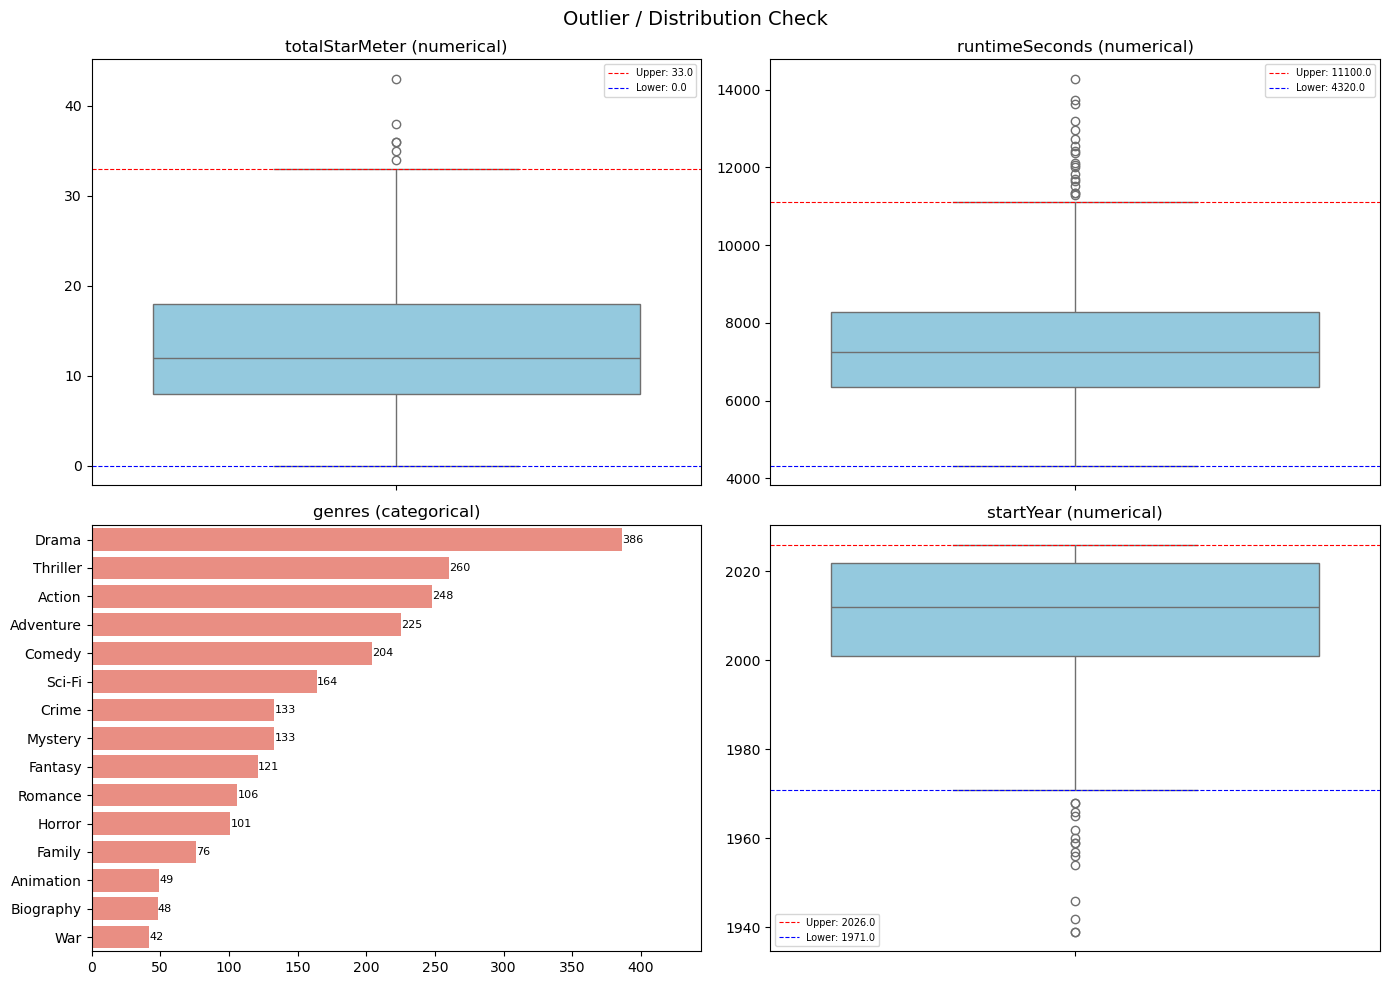

In [ ]:
def plot_outliers(df, columns, ncols=2, nrows=2):
    per_page = ncols * nrows
    chunks = [columns[i:i+per_page] for i in range(0, len(columns), per_page)]

    for chunk in chunks:
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
        axes = axes.flatten()

        for i, col in enumerate(chunk):
            ax = axes[i]

            if col not in df.columns:
                ax.set_visible(False)
                continue

            if pd.api.types.is_numeric_dtype(df[col]):
                data = df[col].dropna()
                sns.boxplot(y=data, ax=ax, color="skyblue")

                Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
                IQR = Q3 - Q1
                lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

                data_sorted = data.sort_values()
                actual_upper = data_sorted[data_sorted <= upper].max()
                actual_lower = data_sorted[data_sorted >= lower].min()

                ax.axhline(actual_upper, color="red", linestyle="--", linewidth=0.8, label=f"Upper: {actual_upper:.1f}")
                ax.axhline(actual_lower, color="blue", linestyle="--", linewidth=0.8, label=f"Lower: {actual_lower:.1f}")
                ax.legend(fontsize=7)
                ax.set_title(f"{col} (numerical)")

            else:
                series = df[col].dropna()

                def parse_entry(x):
                    if isinstance(x, list):
                        return x
                    if isinstance(x, str) and x.startswith("["):
                        try:
                            return ast.literal_eval(x)
                        except:
                            return [x]
                    return [x]

                series = series.apply(parse_entry).explode()
                series = series.str.strip().str.strip("'\"")
                counts = series.value_counts().head(15)

                bars = sns.barplot(x=counts.values, y=counts.index, ax=ax, color="salmon")
                for bar, count in zip(bars.patches, counts.values):
                    ax.text(
                        bar.get_width() + 0.3,
                        bar.get_y() + bar.get_height() / 2,
                        str(count), va="center", ha="left", fontsize=8
                    )
                ax.set_xlim(0, counts.values[0] * 1.15)
                ax.set_title(f"{col} (categorical)")

            ax.set_xlabel("")
            ax.set_ylabel("")

        for j in range(len(chunk), per_page):
            axes[j].set_visible(False)

        plt.suptitle("Outlier / Distribution Check", fontsize=14)
        plt.tight_layout()
        plt.show()

plot_outliers(df, ["totalStarMeter", "runtimeSeconds", "genres", "startYear"])

In [12]:
def get_outliers(df, columns):
    outlier_dict = {}

    for col in columns:
        if col not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)][["id", "primaryTitle", col]].copy()
        outliers["direction"] = outliers[col].apply(lambda x: "above upper" if x > upper else "below lower")

        print(f"Column: {col} | Number of Outliers: {len(outliers)} | lower: {lower:.1f}, upper: {upper:.1f})")
        display(outliers.reset_index(drop=True))

        outlier_dict[col] = outliers

    return outlier_dict

outlier_dict = get_outliers(df, ["totalStarMeter", "aggregateRating", "runtimeSeconds", "startYear"])

Column: totalStarMeter | Number of Outliers: 6 | lower: -7.0, upper: 33.0)


,id,primaryTitle,totalStarMeter,direction
0,tt12042730,Project Hail Mary,36,above upper
1,tt28650488,The Super Mario Galaxy Movie,43,above upper
2,tt33978029,Ready or Not 2: Here I Come,36,above upper
3,tt26443597,Zootopia 2,38,above upper
4,tt30851137,The Bride!,34,above upper
5,tt1596363,The Big Short,35,above upper


Column: runtimeSeconds | Number of Outliers: 19 | lower: 3480.0, upper: 11160.0)


,id,primaryTitle,runtimeSeconds,direction
0,tt0049833,The Ten Commandments,13200.0,above upper
1,tt1757678,Avatar: Fire and Ash,11820.0,above upper
2,tt0052618,Ben-Hur,12720.0,above upper
3,tt0108052,Schindler's List,11700.0,above upper
4,tt1630029,Avatar: The Way of Water,11520.0,above upper
5,tt0120689,The Green Mile,11340.0,above upper
6,tt0167260,The Lord of the Rings: The Return of the King,12060.0,above upper
7,tt0120338,Titanic,11640.0,above upper
8,tt5537002,Killers of the Flower Moon,12360.0,above upper
9,tt0071562,The Godfather Part II,12120.0,above upper


Column: startYear | Number of Outliers: 15 | lower: 1969.5, upper: 2053.5)


,id,primaryTitle,startYear,direction
0,tt0049833,The Ten Commandments,1956.0,below lower
1,tt0052618,Ben-Hur,1959.0,below lower
2,tt0050083,12 Angry Men,1957.0,below lower
3,tt0064116,Once Upon a Time in the West,1968.0,below lower
4,tt0062622,2001: A Space Odyssey,1968.0,below lower
5,tt0060196,"The Good, the Bad and the Ugly",1966.0,below lower
6,tt0059742,The Sound of Music,1965.0,below lower
7,tt0053291,Some Like It Hot,1959.0,below lower
8,tt0032138,The Wizard of Oz,1939.0,below lower
9,tt0054215,Psycho,1960.0,below lower
